In [23]:
import os
import argparse

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb
import pandas as pd

from datatree import open_datatree
from scipy import stats
from scipy.stats import describe

from var_assim.plotting.presets import get_presets
from var_assim.plotting.bias_perc_error_over_time import make_cleaned_datatree_list
from var_assim.plotting.filtering import filter_by_max_conceivable
from var_assim.plotting.pproc import get_angle_r2, get_angles_for_dt_list
from var_assim.config import PRIOR_PATH, NOISE_PATH, TRUTH_PATH, WINDOW_PATH
from var_assim.calibration.priors import ClimateModelPriors
from var_assim.calibration.noise import ClimateModelNoise
from var_assim.calibration.truth import ClimateModelTruth
from var_assim.calibration.windowing import AssimilationWindowing

In [2]:
presets, basefile = get_presets()
plt.rcParams.update(presets)
SAVE_FIGS = True

In [14]:
# simulation config
cwd = os.getcwd()
prefix = 'var-assim-output'
ssp = 'ssp245'
model = 'pco2geowc'
reg_noise = False
TMIN = 2025
AR = '1'
angles_file = ['9', '12', '14', '17', '21', '33']
ECS = 3.0
DEGpDEC = '0.1'
NYRSRAMP = 50
Nwinds = '14custom'
windowing_config = 'original'
Nens = 500
first_wind = '2027'

# import files and convert to datatrees
if model == 'pco2geowc_nn':
    fnames = [
        cwd + '/../../data/output/' + model + '/'
        + prefix + '_' + ssp + '_' + model + '_TMIN' + str(TMIN) + '_THETA' + th + '_ECS' + str(ECS)
        + '_DEGpDEC' + DEGpDEC + '_NYRSRAMP' + str(NYRSRAMP) + '_Nwinds' + Nwinds + '_Nens' + str(Nens) + '.nc'
        for th in angles_file
    ]

else:    
    fnames = [
        cwd + '/../../data/output/' + model + '/'
        + prefix + '_' + ssp + '_' + model + '_' + windowing_config + '_AR' + AR
        + '_TMIN' + str(TMIN) + '_THETA' + th + '_ECS' + str(ECS)
        + '_DEGpDEC' + DEGpDEC + '_NYRSRAMP' + str(NYRSRAMP) + '_Nens' + str(Nens) + '.nc'
        for th in angles_file
    ]

In [4]:
cli_args = argparse.Namespace(
    model=model,
    ssp=ssp,
    noise_model=f"AR{AR}" if model != 'pco2geowc_nn' else 'nn',
    tmin=TMIN,
    AR=AR,
    ECS=ECS,
    DEGpDEC=DEGpDEC,
    NYRSRAMP=NYRSRAMP,
    Nwinds=Nwinds,
    Nens=Nens,
    reg_noise=reg_noise,
    windowing=windowing_config
)

Noise = ClimateModelNoise.from_cli_and_yaml(cli_args, NOISE_PATH)
Prior = ClimateModelPriors.from_cli_and_yaml_and_noise(cli_args, PRIOR_PATH, Noise)
Windowing = AssimilationWindowing.from_cli_and_yaml(cli_args, WINDOW_PATH)

In [5]:
dt_meta = open_datatree(fnames[0], engine='netcdf4')

In [ ]:
relevant_vars = ['cost_hist', 'controls', 'controls_hist']
all_vars = [x for x in dt_meta[first_wind].ds.data_vars]
dropped_vars = [v for v in all_vars if v not in relevant_vars]
dropped_vars


['data_final',
 'l2s',
 'costs',
 'data_hist',
 'l2_hist',
 'flag',
 'obs',
 'data_truth',
 'controls_truth']

In [8]:
dts_clean = make_cleaned_datatree_list(fnames, angles_file, dropped_vars, THRESHOLD=1e-2)

Processing angle = 9...
Found 15 nodes in tree
Processing node 1: /2027
  Memory: 7.4 MB
  Result: 500 kept, 0 filtered
Processing node 2: /2029
  Memory: 8.2 MB
  Result: 500 kept, 0 filtered
Processing node 3: /2031
  Memory: 9.0 MB
  Result: 497 kept, 3 filtered
Processing node 4: /2033
  Memory: 9.7 MB
  Result: 495 kept, 5 filtered
Processing node 5: /2035
  Memory: 10.5 MB
  Result: 499 kept, 1 filtered
Processing node 6: /2037
  Memory: 11.3 MB
  Result: 497 kept, 3 filtered
Processing node 7: /2039
  Memory: 12.1 MB
  Result: 497 kept, 3 filtered
Processing node 8: /2041
  Memory: 12.8 MB
  Result: 495 kept, 5 filtered
Processing node 9: /2043
  Memory: 13.6 MB
  Result: 495 kept, 5 filtered
Processing node 10: /2045
  Memory: 14.4 MB
  Result: 497 kept, 3 filtered
Processing node 11: /2047
  Memory: 15.2 MB
  Result: 494 kept, 6 filtered
Processing node 12: /2049
  Memory: 16.0 MB
  Result: 496 kept, 4 filtered
Processing node 13: /2075
  Memory: 26.1 MB
  Result: 498 kept, 2 

In [9]:
# important simulation constants
L_CEN = Prior.L_CEN
G_CEN = Prior.G_CEN
EPS_CEN = Prior.EPS_CEN
F_EFF_GEO = 0.09  # hard constant
ALPHA_R1_CEN = Prior.ALPHA_CEN[0]
ALPHA_R2_CEN = Prior.ALPHA_CEN[1]

In [10]:
dat = dts_clean[0]

In [11]:
angles_tr = np.zeros(6)

for idx, angle in enumerate(angles_file):
    tmp_cli = argparse.Namespace(
        model=model,
        ssp=ssp,
        noise_model=f"AR{AR}" if model != 'pco2geowc_nn' else 'nn',
        TMIN=TMIN,
        theta=float(angle),
        AR=AR,
        ecs=ECS,
        DEGpDEC=DEGpDEC,
        NYRSRAMP=NYRSRAMP,
        Nwinds=Nwinds,
        Nens=Nens,
        reg_noise=reg_noise
    )
    tmp_truth = ClimateModelTruth.from_cli_and_yaml(tmp_cli, TRUTH_PATH)

    angles_tr[idx] = get_angle_r2(
        tmp_truth.ALPHA_TR[0], tmp_truth.ALPHA_TR[1],
        tmp_truth.BETA_TR[0], tmp_truth.BETA_TR[1],
        tmp_truth.L_TR, tmp_truth.EPS_TR, tmp_truth.G_TR
    )

angles_tr

array([ 8.91821011, 11.92773783, 14.85034704, 16.7546802 , 21.13149999,
       33.02569211])

In [15]:
# pull prior distributions
prior_a1 = dat[first_wind].ds.controls_hist.sel(vari='ALPHA_R1', iter=0).values
prior_b1 = dat[first_wind].ds.controls_hist.sel(vari='BETA_R1', iter=0).values
prior_a2 = dat[first_wind].ds.controls_hist.sel(vari='ALPHA_R2', iter=0).values
prior_b2 = dat[first_wind].ds.controls_hist.sel(vari='BETA_R2', iter=0).values
prior_l = dat[first_wind].ds.controls_hist.sel(vari='L', iter=0).values
prior_g = dat[first_wind].ds.controls_hist.sel(vari='G', iter=0).values
prior_eps = dat[first_wind].ds.controls_hist.sel(vari='EPS', iter=0).values

# compute priors
angles_prior = np.zeros(Nens)
for i in range(Nens):
    angles_prior[i] = get_angle_r2(prior_a1[i], prior_a2[i], prior_b1[i], prior_b2[i], prior_l[i], prior_eps[i], prior_g[i])

# describe for the people
describe(angles_prior, nan_policy='omit')

DescribeResult(nobs=500, minmax=(2.434852807920853, 32.915740291750495), mean=14.834283963146834, variance=24.169600176999094, skewness=0.6151349513265082, kurtosis=0.5855141366574115)

In [16]:
winds = np.array([w[1] for w in Windowing.windows])
windss = [str(w) for w in winds]

In [17]:
angles = get_angles_for_dt_list(dts_clean, windss, Nens)

In [18]:
ANGLE_MAX_CONCEIVABLE = 50.
angles_filtered = filter_by_max_conceivable(angles, ANGLE_MAX_CONCEIVABLE)
angles_filtered.shape

(6, 14, 500)

In [19]:
# prepare data for plotting
tr_, yr_ = 2, '2027'  # choose true value index and assimilation year ('obs up to X')
ds = dts_clean[tr_][yr_].ds

angles_sel = angles[tr_, -3]

data = np.zeros((12, Nens))
data[0] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='L').values)
data[1] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='G').values)
data[2] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='EPS').values)
data[3] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='C1').values)
data[4] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='C2').values)
data[5] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='F1_CO2').values)
data[6] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='ALPHA_R1').values)
data[7] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='ALPHA_R2').values)
data[8] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='BETA_R1').values/0.09)
data[9] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='BETA_R2').values/0.09)
data[10] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, angles_sel)
data[11] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, angles_prior)

In [20]:
df_all = pd.DataFrame(data=data.T,
    columns=[r'$\lambda$ (K / W m$^{-2}$)', r'$\gamma$ (K / W m$^{-2}$)', r'$\varepsilon$ ($-$)', r'$C_1$', r'$C_2$',
             r'$f^{(CO_2)}_1$ (W m$^{-2})$', r'$\alpha_{R1}$ ($-$)', r'$\alpha_{R2}$ ($-$)',
             r'$\beta_{R1}$ (K / W m$^{-2}$)', r'$\beta_{R2}$ (K / W m$^{-2}$)', r'$\vartheta_{2027}$ (Degrees)', r'$\vartheta_{prior}$ (Degrees)']
)

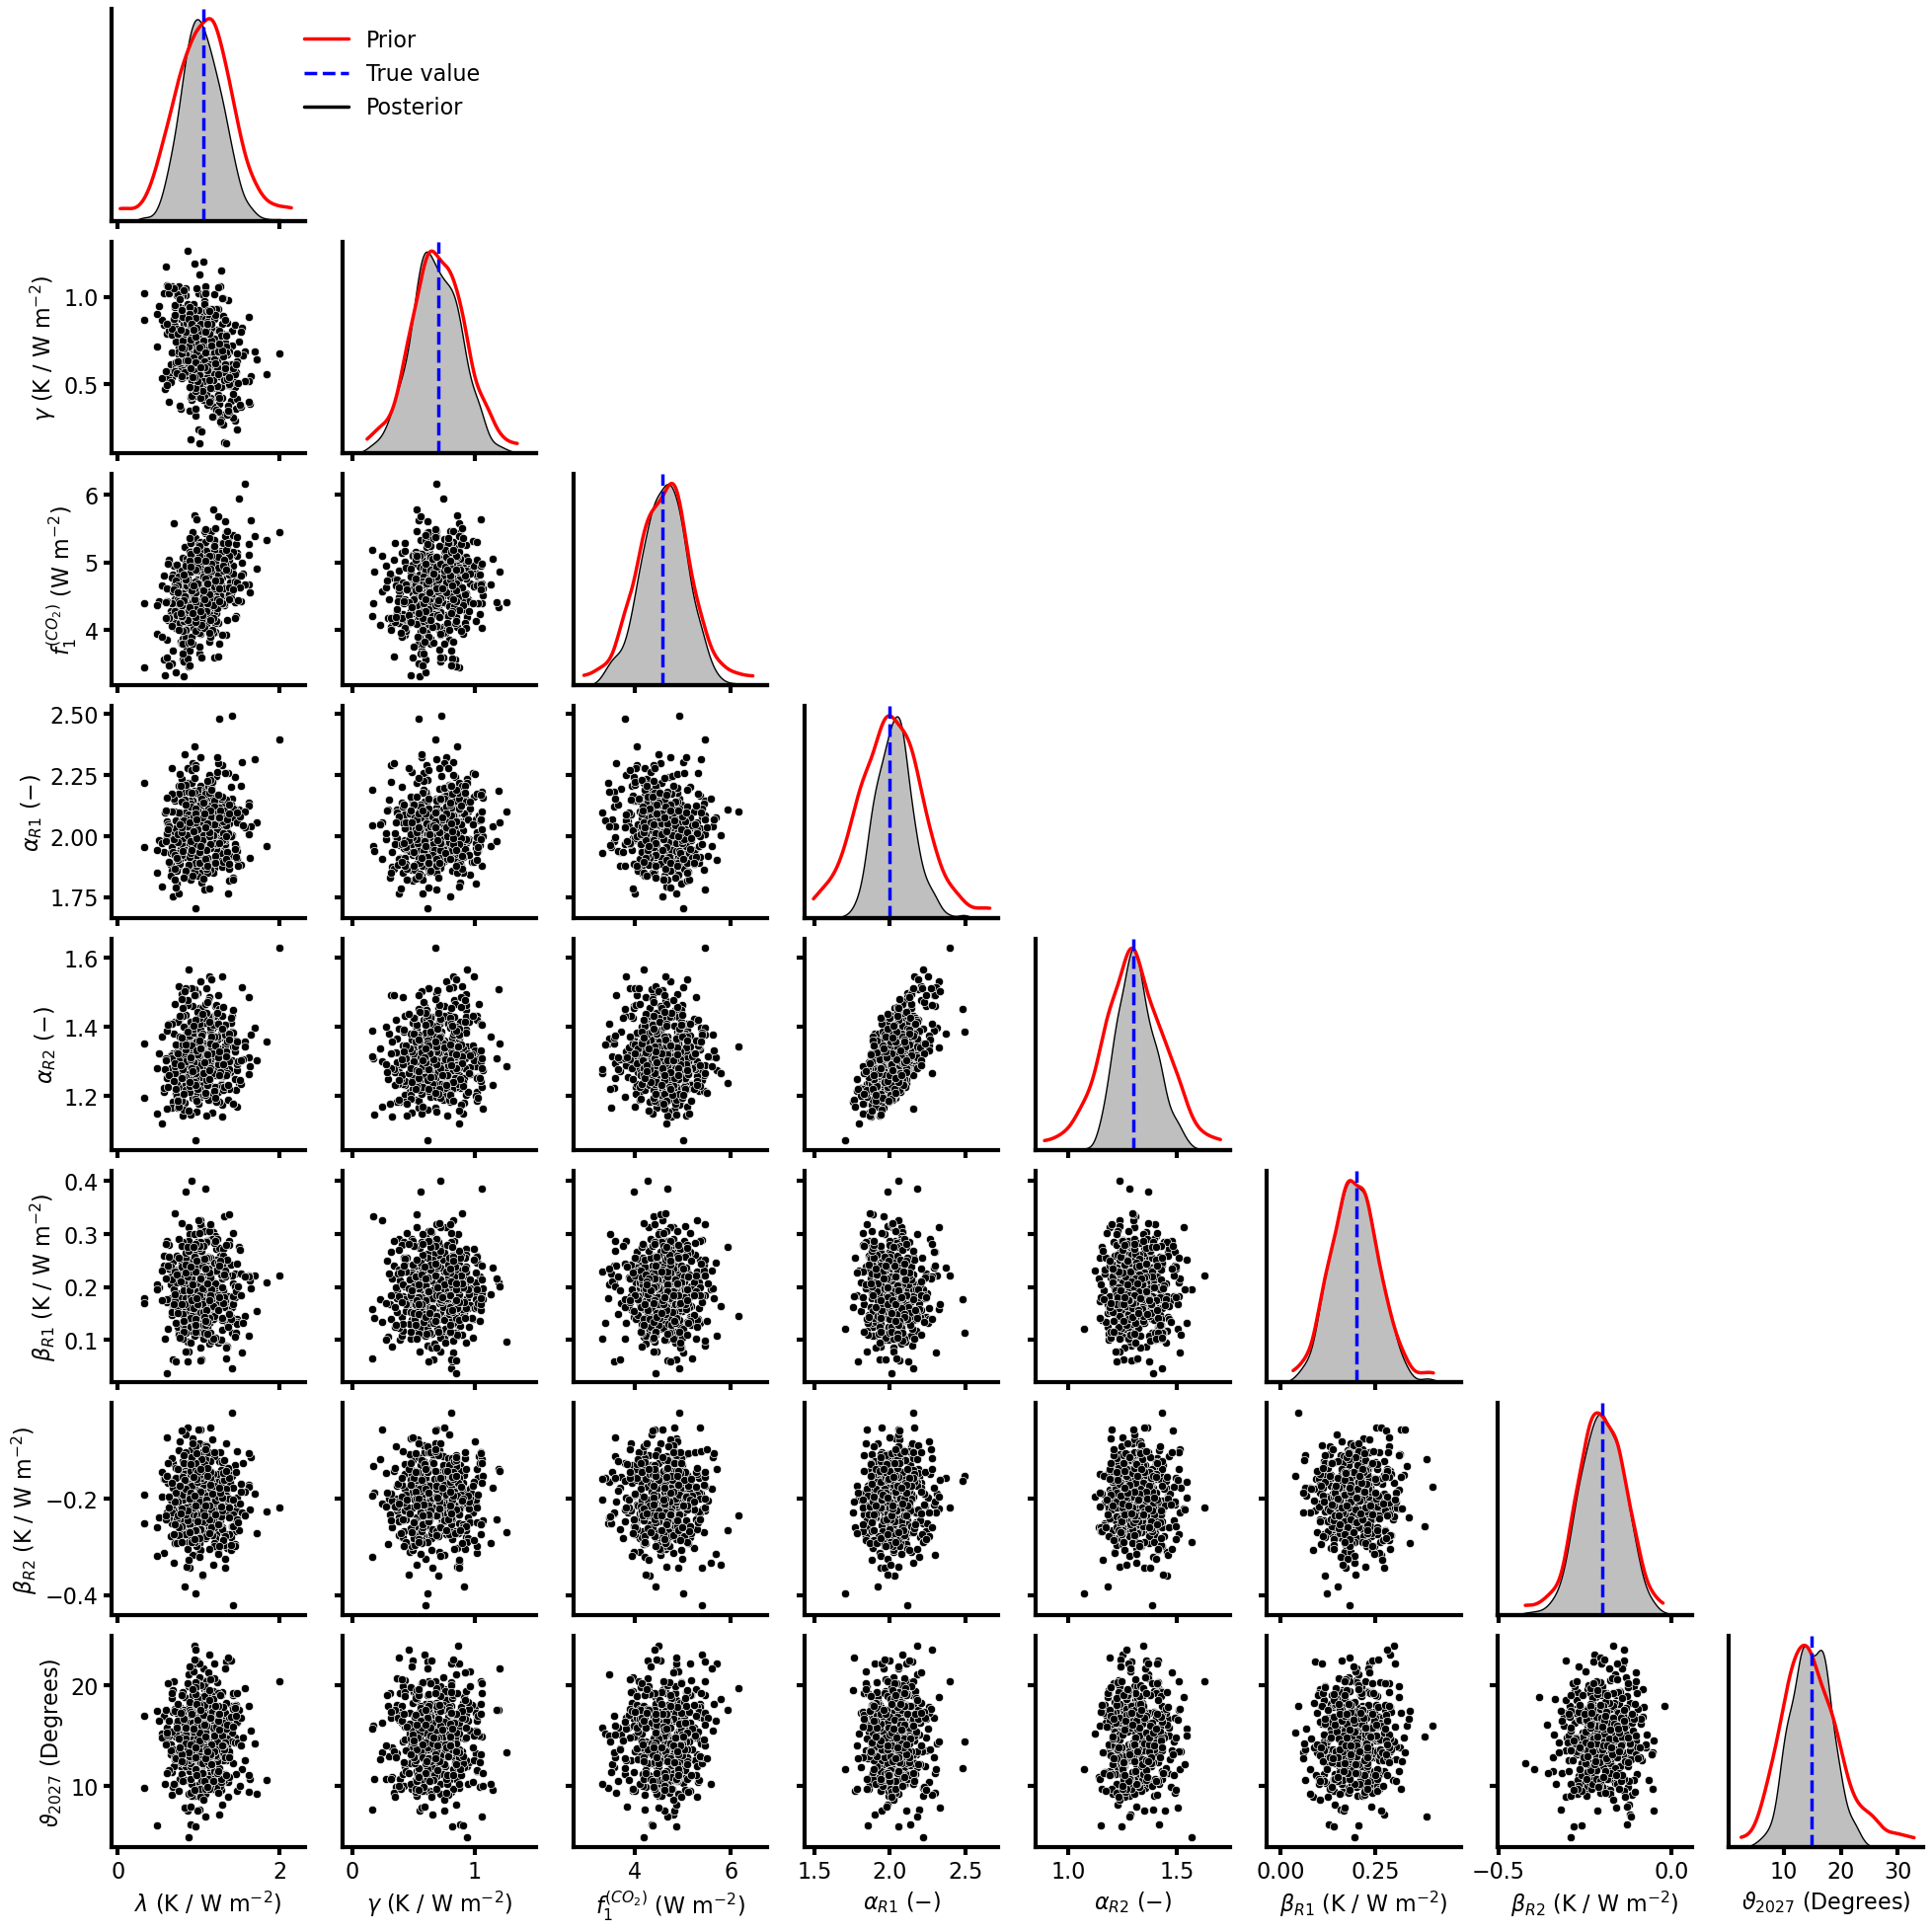

In [27]:

pp = sb.pairplot(df_all, vars=[r'$\lambda$ (K / W m$^{-2}$)', r'$\gamma$ (K / W m$^{-2}$)',
                               r'$f^{(CO_2)}_1$ (W m$^{-2})$', r'$\alpha_{R1}$ ($-$)', r'$\alpha_{R2}$ ($-$)', r'$\beta_{R1}$ (K / W m$^{-2}$)', 
                               r'$\beta_{R2}$ (K / W m$^{-2}$)', r'$\vartheta_{2027}$ (Degrees)'],
                 diag_kind='kde', corner=True, dropna=True)

prior_f = np.random.normal(4.58, 0.519, size=500)
prior_samples = [prior_l, prior_g, prior_f, prior_a1, prior_a2, prior_b1/0.09, prior_b2/0.09, angles_prior]
var_truth = [L_CEN, G_CEN, 4.58, 2, 1.3, 0.018/0.09, -0.018/0.09, angles_tr[tr_]]

# add priors on the diagonals
for i, ax in enumerate(pp.diag_axes):
    x = np.linspace(min(prior_samples[i]), max(prior_samples[i]), 200)
    zeros = np.zeros_like(x)
    
    kde = stats.gaussian_kde(prior_samples[i])

    ax2 = ax.twinx()
    ax2.plot(x, kde(x), 'r-', label='Prior', zorder=-1)
    ax2.axvline(var_truth[i], linestyle='dashed', color='b', label="True value")
    ax2.set_xlim((ax.get_xlim()[0], ax.get_xlim()[1]))
    
    #ax2.fill_between(x, zeros, kde(x), alpha=0.3, color='r', zorder=-1)
    
    ax2.set_ylabel('')
    ax2.set_yticks([])

    if i == 0:
        ax2.plot([2.0], [0], 'k-', label="Posterior")
        ax2.legend(bbox_to_anchor=(2.0, 1.0))

if SAVE_FIGS:
    filename = 'corner-regional.png'
    # pp.savefig(basefile + filename)

In [ ]:
pp = sb.pairplot(df_all,
                diag_kind='kde', corner=True, dropna=True)

In [ ]:
from scipy import stats
# Assuming your dataframe is called 'df'
theta_col = r'$\vartheta$ (Degrees)'

# Get the independent variable (theta)
theta = df_all[theta_col]

results = {}
r_tot = 0

# Loop through each column
for col in df_all.columns:
    # Skip the theta column itself
    if col == theta_col or col == 'ECS (K)' or col == 'TCR (K)':
        continue
    
    # Get the dependent variable
    y = df_all[col]
    
    # Remove NaN values
    mask = ~(np.isnan(theta) | np.isnan(y))
    theta_clean = theta[mask]
    y_clean = y[mask]
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        theta[mask], y[mask]
    )

    r_tot += r_value**2
    
    results[col] = {
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_value**2,
        'p_value': p_value,
        'std_err': std_err
    }

# Convert to DataFrame and sort by R² (descending)
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('r_squared', ascending=False)

print(results_df)
print(f"\n\nVariables ranked by variance explained (R²):")
print("="*60)
for i, (var, row) in enumerate(results_df.iterrows(), 1):
    print(f"{i}. {var}")
    print(f"   R² = {row['r_squared']/r_tot:.4f} ({row['r_squared']*100/r_tot:.2f}% variance explained)")
    print(f"   Slope = {row['slope']:.4f}, p-value = {row['p_value']:.4e}\n")